### SUPPLY CHAIN ANALYTICS PROJECT - STAGE 2 (PYTHON)
#### DataCo Global Order & Logistics Data

WHAT THIS FILE DOES : 
 1. Connects to the MySQL database we already built in Stage 1
 2. Pulls all 7 tables into pandas
 3. Double-checks the data is clean (no surprises)
 4. Calculates the important numbers (KPIs) for our 4 business problems
 5. Makes simple charts to see the patterns
 6. Writes down what each chart/number means for the business

#### Import Libararie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

pd.set_option("display.max_columns", 30)
sns.set_style("whitegrid")

#### CONNECT TO MYSQL AND LOAD THE 7 TABLES

In [4]:
db_user = "root"
db_password = "your_password"
db_host = "localhost"
db_port = 3306
db_name = "Supply_Chain"

connection_string = f"mysql+pymysql://{'root'}:{'Saurabh1405'}@{db_host}:{db_port}/{db_name}"
engine = create_engine(connection_string)

print("Successfully Connected to Database")

Successfully Connected to Database


In [5]:
print("Step 1: Loading tables from MySQL...")

dim_date = pd.read_sql("SELECT * FROM Dim_Date", engine)
dim_customers = pd.read_sql("SELECT * FROM Dim_Customers", engine)
dim_locations = pd.read_sql("SELECT * FROM Dim_Locations", engine)
dim_products = pd.read_sql("SELECT * FROM Dim_Products", engine)
dim_shipping_mode = pd.read_sql("SELECT * FROM Dim_Shipping_Mode", engine)
fact_orders = pd.read_sql("SELECT * FROM Fact_Orders", engine)
fact_shipments = pd.read_sql("SELECT * FROM Fact_Shipments", engine)

Step 1: Loading tables from MySQL...


#### Verify Tables Counts

In [6]:
print("Done. Row counts:")
print("  Dim_Date:", len(dim_date))
print("  Dim_Customers:", len(dim_customers))
print("  Dim_Locations:", len(dim_locations))
print("  Dim_Products:", len(dim_products))
print("  Dim_Shipping_Mode:", len(dim_shipping_mode))
print("  Fact_Orders:", len(fact_orders))
print("  Fact_Shipments:", len(fact_shipments))

Done. Row counts:
  Dim_Date: 1133
  Dim_Customers: 20652
  Dim_Locations: 3772
  Dim_Products: 118
  Dim_Shipping_Mode: 4
  Fact_Orders: 180519
  Fact_Shipments: 180519


#### Re-CHECK THE DATA IS CLEAN

In [7]:
print("\nStep 2: Checking for missing values...")
all_tables = {
    "Dim_Date": dim_date,
    "Dim_Customers": dim_customers,
    "Dim_Locations": dim_locations,
    "Dim_Products": dim_products,
    "Dim_Shipping_Mode": dim_shipping_mode,
    "Fact_Orders": fact_orders,
    "Fact_Shipments": fact_shipments,
}


Step 2: Checking for missing values...


In [8]:
for table_name, table_data in all_tables.items():
    missing_counts = table_data.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0]  
    if len(missing_counts) == 0:
        print(f"  {table_name}: no missing values")
    else:
        print(f"  {table_name}: {dict(missing_counts)}")

  Dim_Date: no missing values
  Dim_Customers: {'Zipcode': np.int64(3)}
  Dim_Locations: no missing values
  Dim_Products: no missing values
  Dim_Shipping_Mode: no missing values
  Fact_Orders: no missing values
  Fact_Shipments: no missing values


#### Checking Duplicate Values

In [9]:
print("\nChecking for duplicate order IDs...")
duplicate_orders = fact_orders["Order_Item_ID"].duplicated().sum()
duplicate_shipments = fact_shipments["Order_Item_ID"].duplicated().sum()
print("  Duplicate rows in Fact_Orders:", duplicate_orders, "(should be 0)")
print("  Duplicate rows in Fact_Shipments:", duplicate_shipments, "(should be 0)")


Checking for duplicate order IDs...
  Duplicate rows in Fact_Orders: 0 (should be 0)
  Duplicate rows in Fact_Shipments: 0 (should be 0)


#### Date Check

In [10]:
fact_orders["Order_Date"] = pd.to_datetime(fact_orders["Order_Date"])
fact_shipments["Order_Date"] = pd.to_datetime(fact_shipments["Order_Date"])
fact_shipments["Shipping_Date"] = pd.to_datetime(fact_shipments["Shipping_Date"])
dim_date["Date"] = pd.to_datetime(dim_date["Date"])

#### CALCULATE THE KEY NUMBERS (KPIs) FOR EACH BUSINESS PROBLEM

In [11]:
# Problem 1: Are our deliveries reliable? 
total_shipments = len(fact_shipments)
late_shipments = fact_shipments["Late_Delivery_Risk"].sum()
late_delivery_rate = round(late_shipments * 100 / total_shipments, 2)
average_delay_days = round(fact_shipments["Shipping_Delay_Days"].mean(), 2)

In [12]:
# ---- Problem 2: Are some orders riskier than others? ----
risky_statuses = ["CANCELED", "SUSPECTED_FRAUD", "ON_HOLD", "PAYMENT_REVIEW"]
is_risky_order = fact_orders["Order_Status"].isin(risky_statuses)
risk_order_rate = round(is_risky_order.sum() * 100 / len(fact_orders), 2)

is_fraud_order = fact_orders["Order_Status"] == "SUSPECTED_FRAUD"
fraud_rate = round(is_fraud_order.sum() * 100 / len(fact_orders), 2)

In [13]:
# ---- Problem 3: Are we actually making money? ----
total_sales = fact_orders["Sales_Amount"].sum()
total_profit = fact_orders["Profit_Amount"].sum()
overall_profit_margin = round(total_profit / total_sales * 100, 2)

is_loss_making = fact_orders["Profit_Amount"] < 0
loss_making_rate = round(is_loss_making.sum() * 100 / len(fact_orders), 2)

In [14]:
# ---- Problem 4: What do cancelled orders cost us? ----
cancelled_orders = fact_orders[fact_orders["Order_Status"] == "CANCELED"]
cancellation_rate = round(len(cancelled_orders) * 100 / len(fact_orders), 2)
cancelled_sales_value = round(cancelled_orders["Sales_Amount"].sum(), 2)
cancelled_profit_value = round(cancelled_orders["Profit_Amount"].sum(), 2)

#### Print everything in one clean summary

In [15]:
print("\n--- KPI SUMMARY ---")
print(f"Late Delivery Rate:      {late_delivery_rate}%")
print(f"Average Delay:           {average_delay_days} days")
print(f"Risky Order Rate:        {risk_order_rate}%")
print(f"Fraud Rate:              {fraud_rate}%")
print(f"Overall Profit Margin:   {overall_profit_margin}%")
print(f"Loss-Making Order Rate:  {loss_making_rate}%")
print(f"Cancellation Rate:       {cancellation_rate}%")
print(f"Cancelled Sales Value:   ${cancelled_sales_value:,.2f}")
print(f"Cancelled Profit Value:  ${cancelled_profit_value:,.2f}")


--- KPI SUMMARY ---
Late Delivery Rate:      54.83%
Average Delay:           0.57 days
Risky Order Rate:        10.78%
Fraud Rate:              2.25%
Overall Profit Margin:   10.78%
Loss-Making Order Rate:  18.71%
Cancellation Rate:       2.05%
Cancelled Sales Value:   $744,370.39
Cancelled Profit Value:  $75,345.63


#### MAKE SURE PYTHON AGREES WITH SQL (SANITY CHECK)

In [16]:
print("\nStep 4: Comparing Python results to Stage 1 SQL results...")

known_sql_numbers = {
    "Late Delivery Rate": (late_delivery_rate, 54.83),
    "Risky Order Rate": (risk_order_rate, 10.78),
    "Cancelled Sales Value": (cancelled_sales_value, 744370.39),
    "Cancelled Profit Value": (cancelled_profit_value, 75345.63),
}

for kpi_name, (python_answer, sql_answer) in known_sql_numbers.items():
    if abs(python_answer - sql_answer) < 0.5:
        print(f"  {kpi_name}: Python = {python_answer}, SQL = {sql_answer}  -> MATCH")
    else:
        print(f"  {kpi_name}: Python = {python_answer}, SQL = {sql_answer}  -> DOES NOT MATCH, CHECK THIS")


Step 4: Comparing Python results to Stage 1 SQL results...
  Late Delivery Rate: Python = 54.83, SQL = 54.83  -> MATCH
  Risky Order Rate: Python = 10.78, SQL = 10.78  -> MATCH
  Cancelled Sales Value: Python = 744370.39, SQL = 744370.39  -> MATCH
  Cancelled Profit Value: Python = 75345.63, SQL = 75345.63  -> MATCH


#### SIMPLE CHARTS TO SEE THE PATTERNS

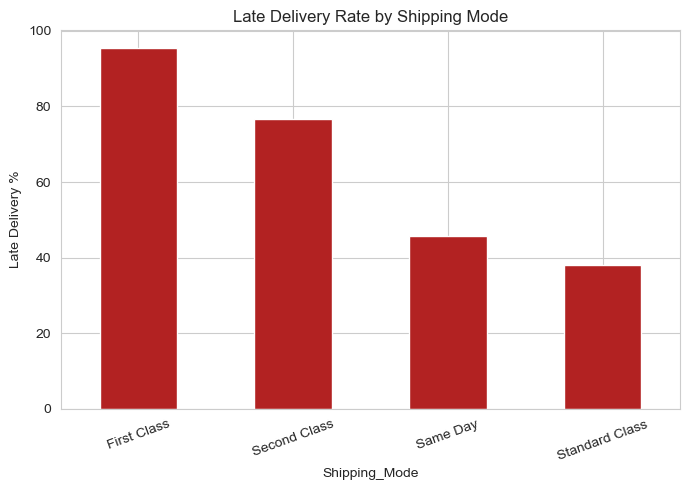

  Saved: chart1_late_delivery_by_mode.png


In [17]:
# --- Chart 1: Late delivery % by shipping mode (Problem 1) ---
shipments_with_mode = fact_shipments.merge(dim_shipping_mode, on="Shipping_Mode_ID")
late_by_mode = shipments_with_mode.groupby("Shipping_Mode")["Late_Delivery_Risk"].mean() * 100
late_by_mode = late_by_mode.sort_values(ascending=False)

plt.figure(figsize=(7, 5))
late_by_mode.plot(kind="bar", color="firebrick")
plt.title("Late Delivery Rate by Shipping Mode")
plt.ylabel("Late Delivery %")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("chart1_late_delivery_by_mode.png")
plt.show()
plt.close()
print("  Saved: chart1_late_delivery_by_mode.png")

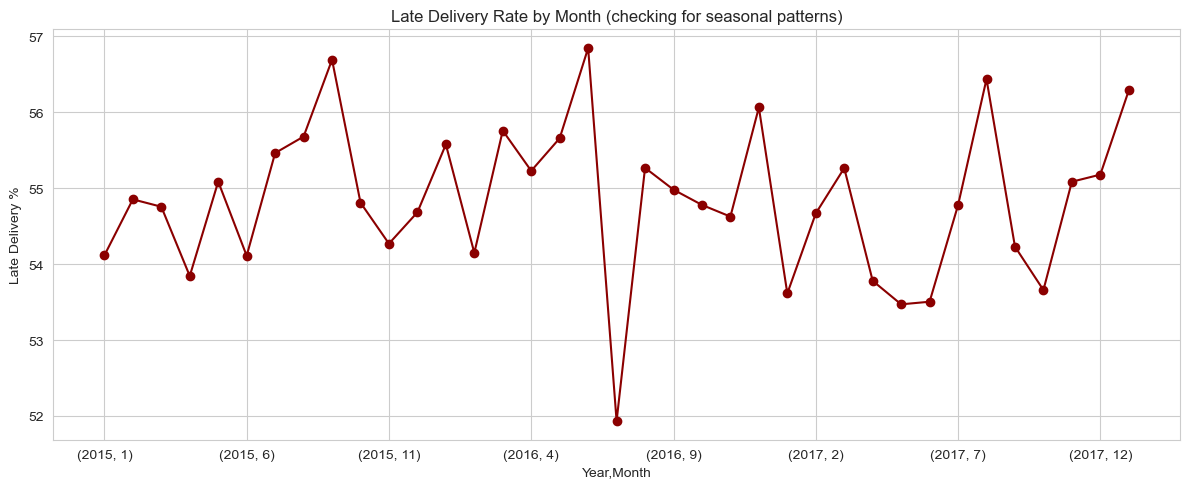

  Saved: chart2_late_delivery_by_month.png


In [18]:
# --- Chart 2: Does late delivery change by month? (Problem 1) ---
shipments_with_date = fact_shipments.merge(dim_date, left_on="Order_Date", right_on="Date")
late_by_month = shipments_with_date.groupby(["Year", "Month"])["Late_Delivery_Risk"].mean() * 100

plt.figure(figsize=(12, 5))
late_by_month.plot(kind="line", marker="o", color="darkred")
plt.title("Late Delivery Rate by Month (checking for seasonal patterns)")
plt.ylabel("Late Delivery %")
plt.tight_layout()
plt.savefig("chart2_late_delivery_by_month.png")
plt.show()
plt.close()
print("  Saved: chart2_late_delivery_by_month.png")

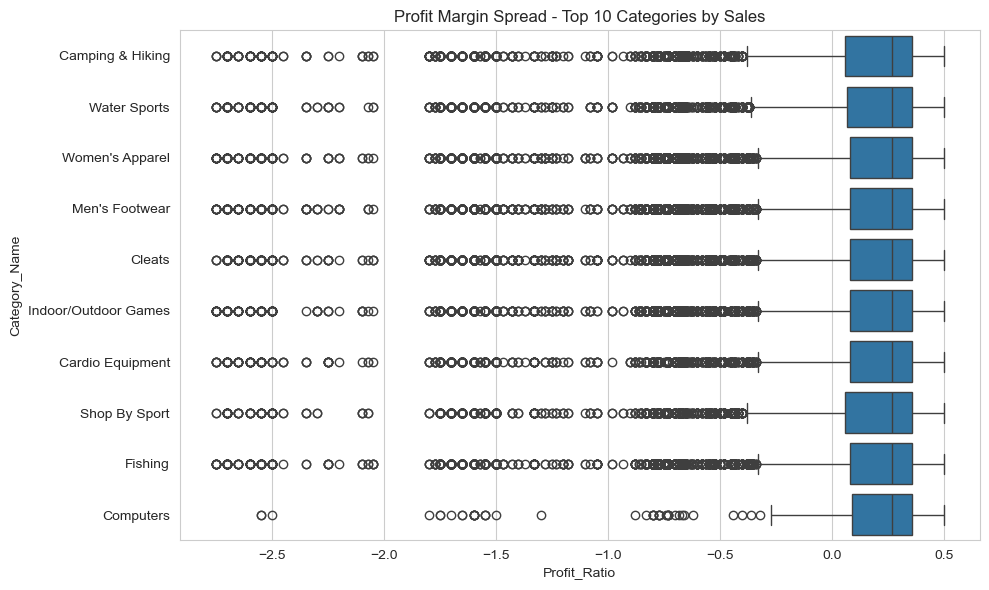

  Saved: chart3_profit_margin_by_category.png


In [19]:
# --- Chart 3: Profit margin by category - box plot (Problem 3) ---
orders_with_category = fact_orders.merge(dim_products[["Product_ID", "Category_Name"]], on="Product_ID")
top_10_categories = (
    orders_with_category.groupby("Category_Name")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
top_category_orders = orders_with_category[orders_with_category["Category_Name"].isin(top_10_categories)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=top_category_orders, x="Profit_Ratio", y="Category_Name")
plt.title("Profit Margin Spread - Top 10 Categories by Sales")
plt.tight_layout()
plt.savefig("chart3_profit_margin_by_category.png")
plt.show()
plt.close()
print("  Saved: chart3_profit_margin_by_category.png")

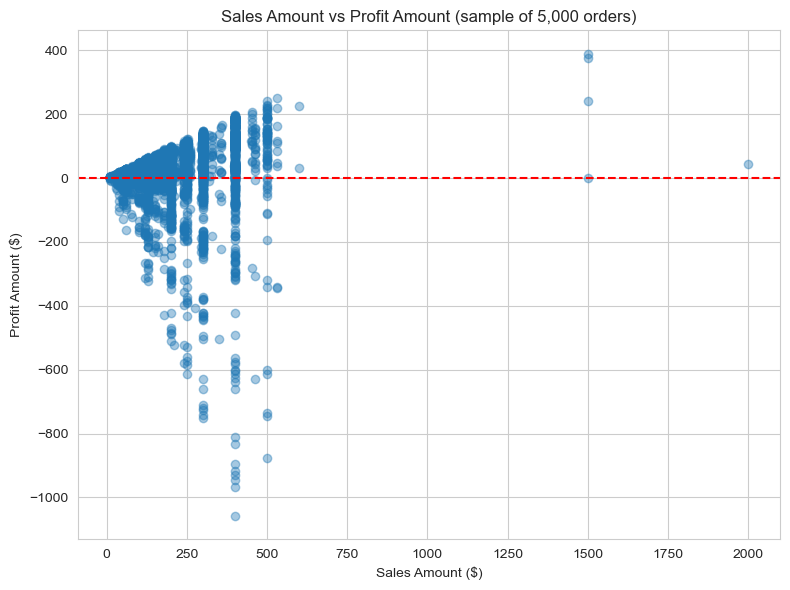

  Saved: chart4_sales_vs_profit.png


In [20]:
# --- Chart 4: Sales amount vs profit amount (Problem 3) ---
# We only plot a sample of 5,000 rows so the chart isn't too crowded to read.
sample_orders = fact_orders.sample(5000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample_orders["Sales_Amount"], sample_orders["Profit_Amount"], alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Sales Amount vs Profit Amount (sample of 5,000 orders)")
plt.xlabel("Sales Amount ($)")
plt.ylabel("Profit Amount ($)")
plt.tight_layout()
plt.savefig("chart4_sales_vs_profit.png")
plt.show()
plt.close()
print("  Saved: chart4_sales_vs_profit.png")

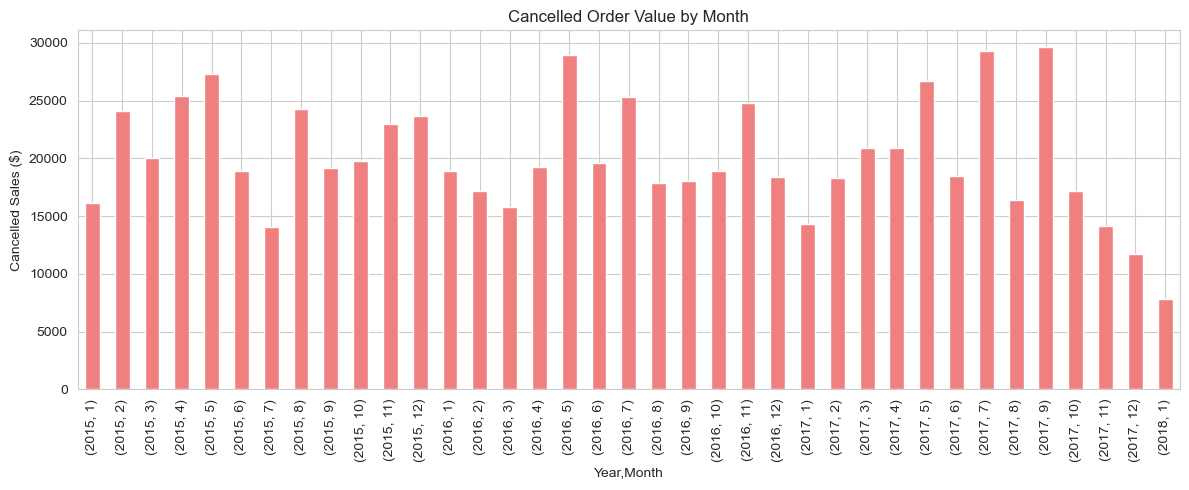

  Saved: chart5_cancelled_value_by_month.png


In [21]:
# --- Chart 5: Cancelled order value over time (Problem 4) ---
cancelled_with_date = cancelled_orders.merge(dim_date, left_on="Order_Date", right_on="Date")
monthly_cancelled = cancelled_with_date.groupby(["Year", "Month"])["Sales_Amount"].sum()

plt.figure(figsize=(12, 5))
monthly_cancelled.plot(kind="bar", color="lightcoral")
plt.title("Cancelled Order Value by Month")
plt.ylabel("Cancelled Sales ($)")
plt.tight_layout()
plt.savefig("chart5_cancelled_value_by_month.png")
plt.show()
plt.close()
print("  Saved: chart5_cancelled_value_by_month.png")

####  BUSINESS INSIGHTS

##### PROBLEM 1 - Shipping Reliability

Finding:
First Class shipping has the highest late-delivery rate among the
four shipping modes.

Evidence:
The chart shows that First Class is around 95% late, while Standard
Class is around 38% late.

Meaning:
The monthly analysis does not show a strong seasonal pattern.
This suggests that the issue is more related to the First Class
shipping process.

Recommendation:
The business should check the First Class carrier and delivery
process to understand why these orders are getting delayed.

##### PROBLEM 2 - Order Risk

Finding:
Around **10.78%** of orders are classified as risky.
This includes cancelled, fraudulent, on-hold, or payment-review orders.

Evidence:
The SQL analysis shows that the risk is present across different
regions, markets, and customer segments.

Meaning:
The problem is not limited to one particular region or customer group.

Recommendation:
The business should improve the overall fraud detection and
payment verification process.

##### PROBLEM 3 - Profitability

Finding:
The category with the highest sales, Fishing, is ranked only around
29th out of about 50 categories in terms of profit margin.

Evidence:
The profit margin and sales-versus-profit charts show that higher
sales do not always result in higher profit. About **18.71%** of all
order lines lose money, spread fairly evenly across categories.

Meaning:
The business may be selling a large number of products but still
earning a lower margin from them.

Recommendation:
The business should review product costs, pricing, and discount
policies to improve overall profitability.

##### PROBLEM 4 - Cancellations

Finding:
Cancelled orders represent 744,370.39 in lost sales and
$75,345.63 in lost profit.

Evidence:
The monthly trend chart shows no clear upward or downward pattern.
Stage 1's SQL analysis also found that the cancellation rate barely
changes by region, shipping mode, or order value.

Meaning:
Cancellations appear to happen close to randomly - there is no single
group of orders driving most of the cost.

Recommendation:
The business should improve general order-verification and payment-
checking processes, rather than targeting one specific region, shipping
mode, or price range.

## Completed Stage 2